# ChurnZero — Customer Churn Prediction

**Team SCodes** · ChurnZero Hackathon 2026

**Run this notebook top-to-bottom.** Each phase builds on the previous one.

---

## Phase 0 — Environment Setup

Install dependencies and import libraries used in Phases 1–4.

In [44]:
!pip install lightgbm xgboost catboost scikit-learn --quiet

In [45]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder  # categoricals -> int codes for tree models (see encoding comments in Phase 3)
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    confusion_matrix,
    precision_recall_curve,
    auc,
)
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

## Phase 1 — Exploratory Data Analysis

Understand the data, churn rate, segment risk, correlations, and leakage before modeling.

In [46]:
# Phase 1: load labeled train and unlabeled test; all paths relative to project folder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

sns.set_style("whitegrid")
warnings.filterwarnings("ignore")

train = pd.read_csv("ChurnZero_dataset_v1.csv")
test = pd.read_csv("ChurnZero_test_v1.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nTrain head:")
print(train.head())

Train shape: (8101, 98)
Test shape: (2026, 97)

Train head:
   customer_id  churn  age  gender marital_status education_level  \
0       133001      0   36  Female        Married         Unknown   
1       133002      1   44    Male         Single     High School   
2       133003      0   46    Male        Married     High School   
3       133004      0   36  Female        Married        Graduate   
4       133005      0   50    Male         Single        Graduate   

   dependent_count occupation_type  annual_income   income_band  ...  \
0                0        Salaried          22256           Low  ...   
1                3       Homemaker          66481        Middle  ...   
2                2        Salaried          98955  Upper-Middle  ...   
3                2         Retired          26735           Low  ...   
4                1        Salaried         165387          High  ...   

  discount_or_fee_waiver_received competitor_bank_offer_awareness  \
0                      

In [47]:
# Phase 1: baseline data-quality audit before feature engineering or modeling
# Data quality checks on train
missing = train.isnull().sum()
missing_cols = missing[missing > 0]

print("Missing values per column:")
print(missing_cols)
print()

if len(missing_cols) > 0:
    missing_pct = (missing_cols / len(train) * 100).round(2)
    print("Percentage of missing values:")
    print(missing_pct.astype(str) + "%")
else:
    print("Percentage of missing values: none")
print()

print("Data types:")
print(train.dtypes)
print()

print("Duplicate rows:", train.duplicated().sum())
print()

print("Churn value counts:")
print(train["churn"].value_counts())
churn_rate = train["churn"].mean() * 100
print(f"\nChurn rate: {churn_rate:.2f}%")

Missing values per column:
app_rating_given    4541
dtype: int64

Percentage of missing values:
app_rating_given    56.05%
dtype: str

Data types:
customer_id                    int64
churn                          int64
age                            int64
gender                           str
marital_status                   str
                              ...   
credit_utilization_6m_avg    float64
avg_quarterly_balance        float64
total_digital_logins           int64
debt_to_income_ratio         float64
digital_engagement_index     float64
Length: 98, dtype: object

Duplicate rows: 0

Churn value counts:
churn
0    6799
1    1302
Name: count, dtype: int64

Churn rate: 16.07%


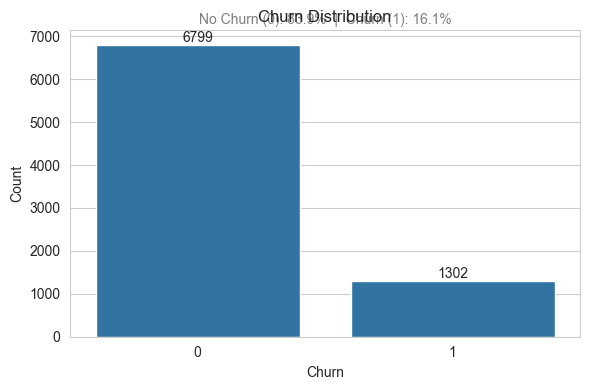

In [48]:
# Phase 1: visualize class imbalance (drives scale_pos_weight and PR-AUC metric later)
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=train, x="churn", order=[0, 1], ax=ax)

for container in ax.containers:
    ax.bar_label(container)

churn_counts = train["churn"].value_counts().sort_index()
churn_pct = churn_counts / len(train) * 100
subtitle = f"No Churn (0): {churn_pct[0]:.1f}%  |  Churn (1): {churn_pct[1]:.1f}%"

ax.set_title("Churn Distribution")
ax.text(0.5, 1.02, subtitle, transform=ax.transAxes, ha="center", fontsize=10, color="gray")
ax.set_xlabel("Churn")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

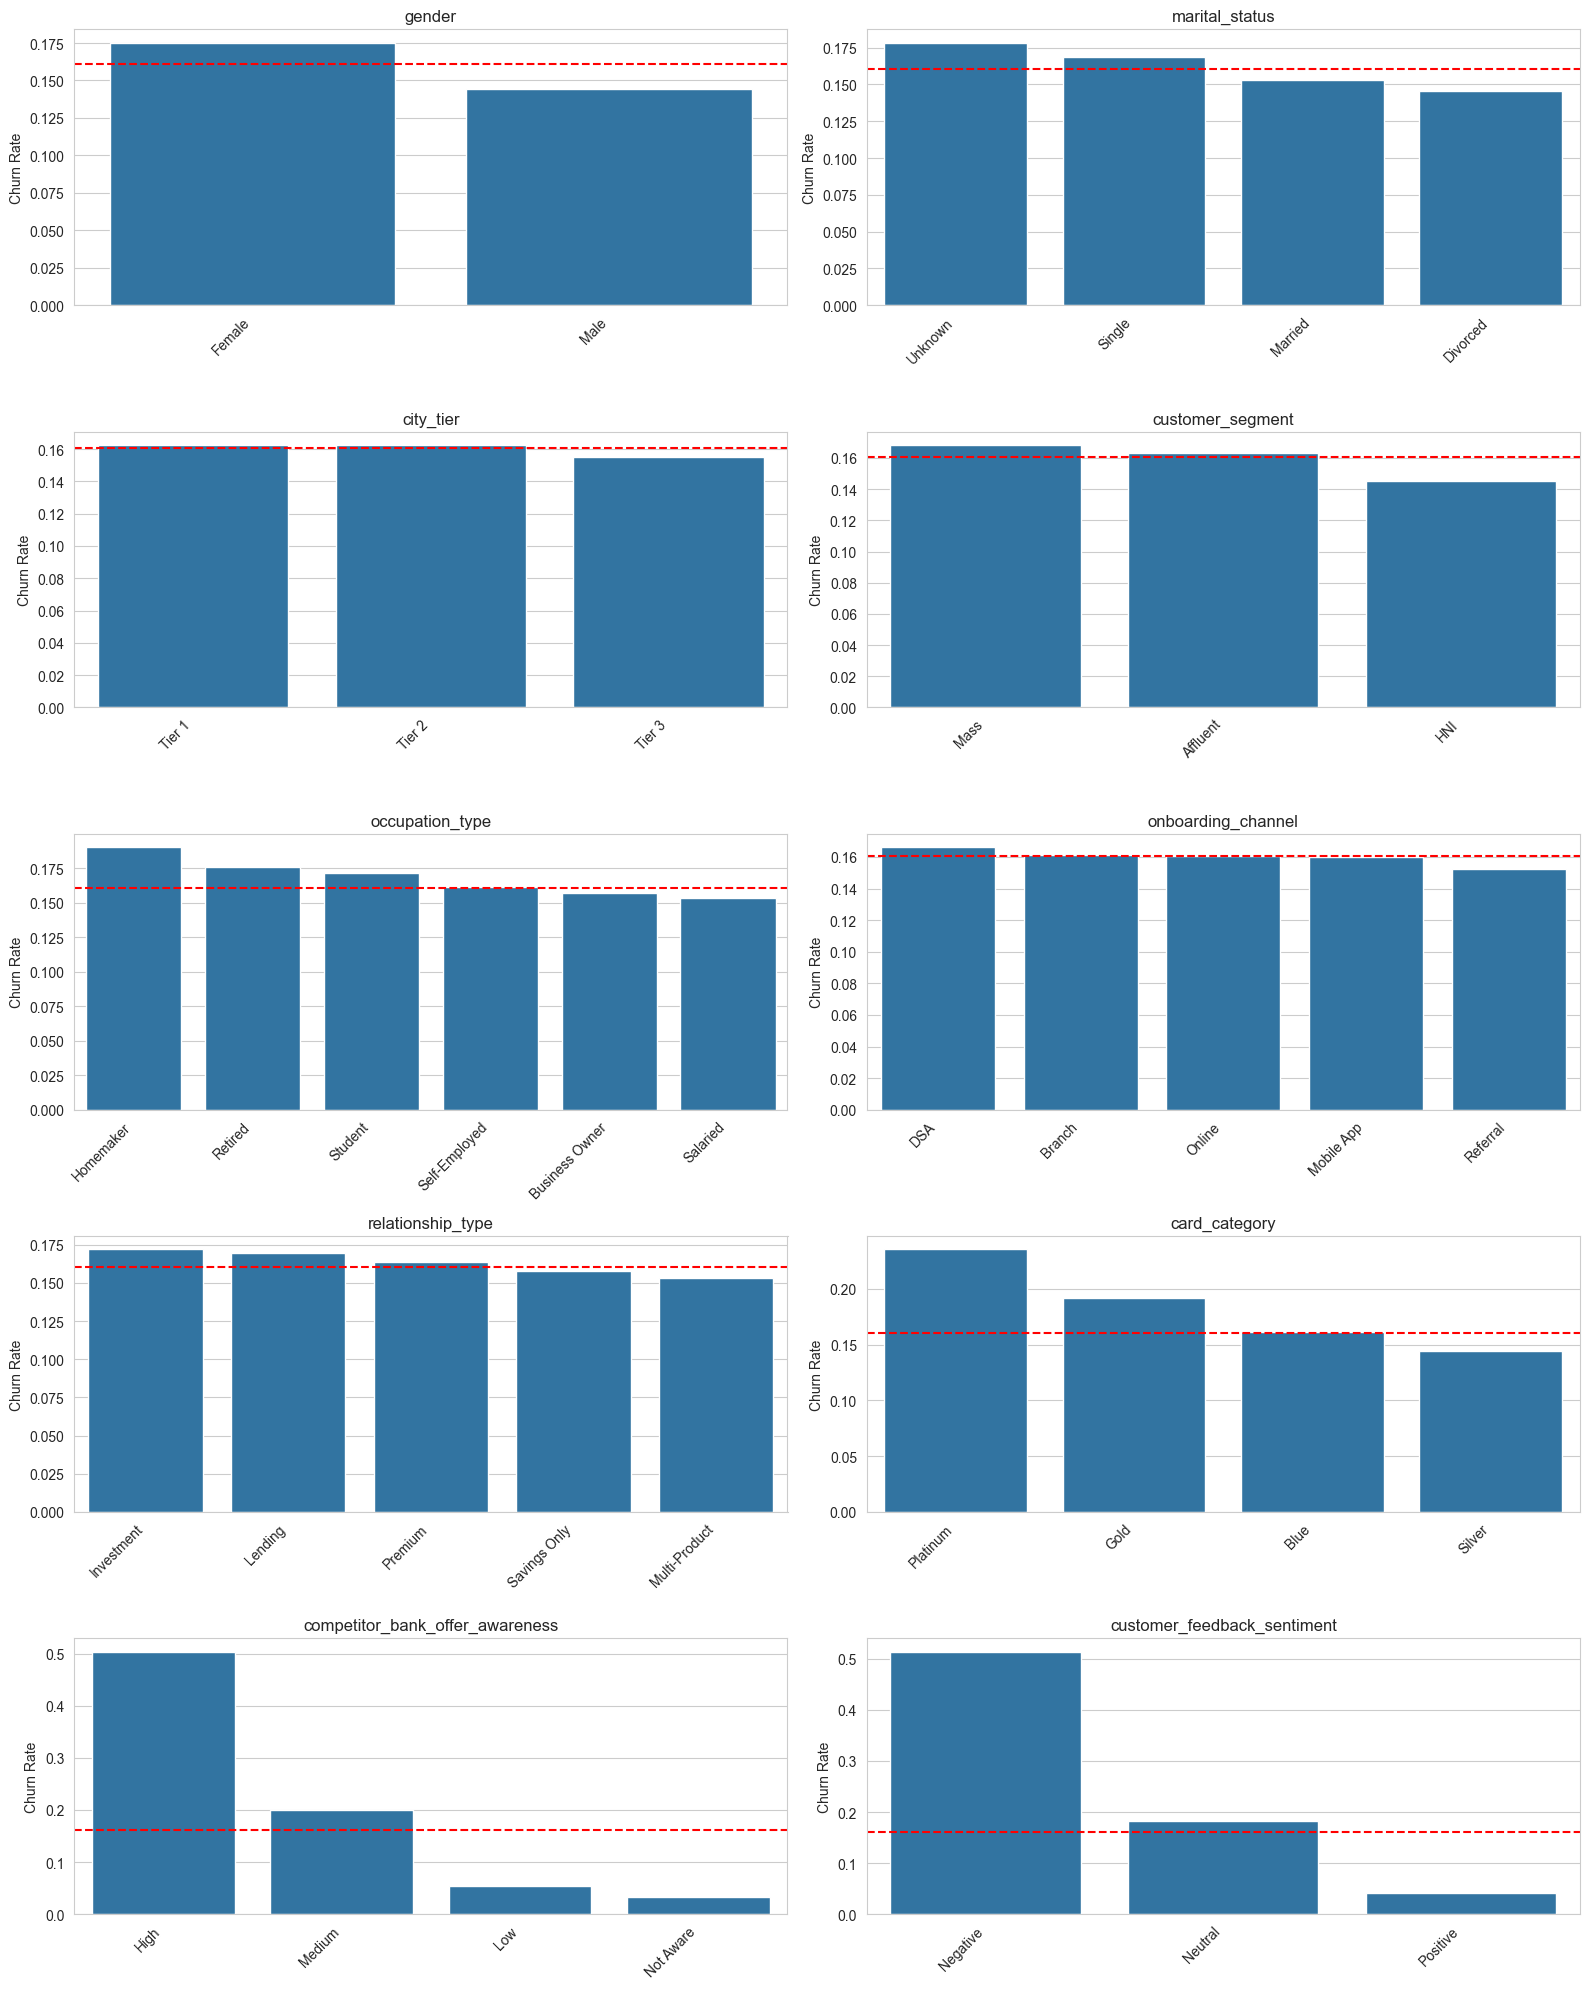

In [49]:
# Phase 1: churn rate by key categorical segments vs overall baseline
cat_cols = [
    "gender",
    "marital_status",
    "city_tier",
    "customer_segment",
    "occupation_type",
    "onboarding_channel",
    "relationship_type",
    "card_category",
    "competitor_bank_offer_awareness",
    "customer_feedback_sentiment",
]

overall_churn_rate = train["churn"].mean()

fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    churn_by_cat = (
        train.groupby(col)["churn"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
    sns.barplot(data=churn_by_cat, x=col, y="churn", order=churn_by_cat[col], ax=ax)
    ax.axhline(overall_churn_rate, color="red", linestyle="--", linewidth=1.5)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Churn Rate")
    ax.tick_params(axis="x", rotation=45)
    plt.setp(ax.get_xticklabels(), ha="right")

plt.tight_layout()
plt.show()

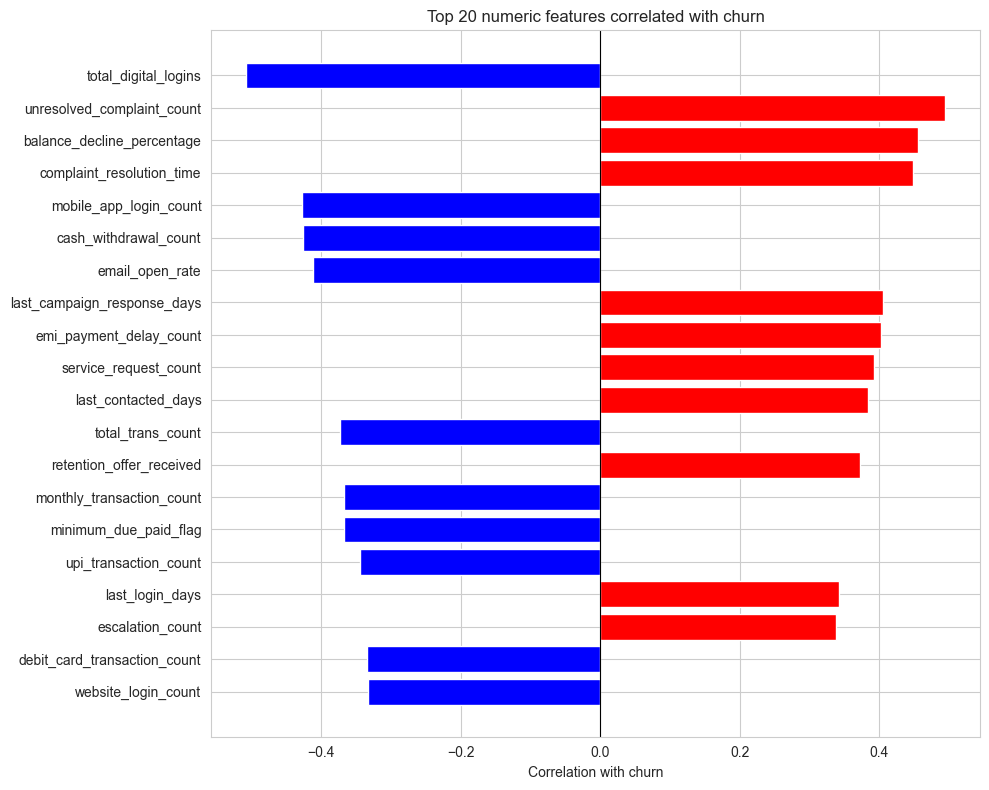

In [50]:
# Phase 1: univariate numeric correlations with churn (leakage screening input)
numeric_cols = train.select_dtypes(include="number").columns.drop(
    ["customer_id", "churn"], errors="ignore"
)

# Pearson correlation vs churn; high |r| motivates leakage review in Phase 3
correlations = train[numeric_cols].corrwith(train["churn"]).dropna()
top_20 = correlations.abs().sort_values(ascending=False).head(20).index
order = correlations[top_20].abs().sort_values(ascending=True).index
top_corr = correlations[order]

colors = ["red" if v > 0 else "blue" for v in top_corr]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_corr.index, top_corr.values, color=colors)
ax.set_title("Top 20 numeric features correlated with churn")
ax.set_xlabel("Correlation with churn")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

In [51]:
# Phase 1: rule-based leakage check — >50% mean shift between churn groups flags risk
leakage_cols = [
    "retention_offer_accepted",
    "competitor_bank_offer_awareness",
    "last_campaign_response_days",
    "retention_offer_received",
    "discount_or_fee_waiver_received",
    "customer_feedback_sentiment",
]

for col in leakage_cols:
    print(f"\n{col}")
    series = train[col]
    if not pd.api.types.is_numeric_dtype(series):
        series = series.astype("category").cat.codes
    group_means = train.assign(_val=series).groupby("churn")["_val"].mean()
    print(group_means)

    mean_0 = group_means.loc[0]
    mean_1 = group_means.loc[1]

    if mean_0 == 0:
        rel_diff = float("inf") if mean_1 != 0 else 0
    else:
        rel_diff = abs(mean_1 - mean_0) / abs(mean_0)

    if rel_diff > 0.5:
        print(f"POTENTIAL LEAKAGE: {col}")


retention_offer_accepted
churn
0    0.097809
1    0.113671
Name: _val, dtype: float64

competitor_bank_offer_awareness
churn
0    1.755405
1    0.923195
Name: _val, dtype: float64

last_campaign_response_days
churn
0     43.835123
1    113.033794
Name: _val, dtype: float64
POTENTIAL LEAKAGE: last_campaign_response_days

retention_offer_received
churn
0    0.150463
1    0.568356
Name: _val, dtype: float64
POTENTIAL LEAKAGE: retention_offer_received

discount_or_fee_waiver_received
churn
0    0.147080
1    0.344854
Name: _val, dtype: float64
POTENTIAL LEAKAGE: discount_or_fee_waiver_received

customer_feedback_sentiment
churn
0    1.54611
1    0.59063
Name: _val, dtype: float64
POTENTIAL LEAKAGE: customer_feedback_sentiment


In [52]:
# Phase 1: handle missing app_rating_given; fit imputation on train only, apply to both sets
missing_count = train["app_rating_given"].isna().sum()
missing_pct = missing_count / len(train) * 100
print(f"Missing app_rating_given (train): {missing_count} ({missing_pct:.2f}%)")

train["app_rating_missing_flag"] = train["app_rating_given"].isna().astype(int)
test["app_rating_missing_flag"] = test["app_rating_given"].isna().astype(int)

# Median from train only — prevents test information leaking into imputation
app_rating_median = train["app_rating_given"].median()
train["app_rating_given"] = train["app_rating_given"].fillna(app_rating_median)
test["app_rating_given"] = test["app_rating_given"].fillna(app_rating_median)

print(f"\nMissing after imputation (train): {train['app_rating_given'].isna().sum()}")
print(f"Missing after imputation (test): {test['app_rating_given'].isna().sum()}")

Missing app_rating_given (train): 4541 (56.05%)

Missing after imputation (train): 0
Missing after imputation (test): 0


### Phase 1 Gate — Validation Report

Confirms missing-data handling and flags columns to exclude in Phase 2.

In [53]:
# Phase 1 gate: confirm data health, leakage status, and readiness before Phase 2
DIVIDER = "=" * 70
LEAKAGE_COLS = [
    "retention_offer_accepted",
    "competitor_bank_offer_awareness",
    "last_campaign_response_days",
    "retention_offer_received",
    "discount_or_fee_waiver_received",
    "customer_feedback_sentiment",
]
issues = []

print(DIVIDER)
print("PHASE 1 VALIDATION REPORT")
print(DIVIDER)

# --- 1. DATA HEALTH ---
print("\n=== 1. DATA HEALTH ===\n")
print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
churn_rate_pct = train["churn"].mean() * 100
print(f"Churn rate:  {churn_rate_pct:.2f}%")

train_missing = train.isnull().sum()
test_missing = test.isnull().sum()
train_missing_cols = train_missing[train_missing > 0]
test_missing_cols = test_missing[test_missing > 0]

print("\nMissing values (train):")
if len(train_missing_cols) == 0:
    print("  None")
else:
    for col, cnt in train_missing_cols.items():
        pct = cnt / len(train) * 100
        print(f"  {col}: {cnt} ({pct:.2f}%)")
        issues.append(f"Train column '{col}' has {cnt} missing values")

print("\nMissing values (test):")
if len(test_missing_cols) == 0:
    print("  None")
else:
    for col, cnt in test_missing_cols.items():
        pct = cnt / len(test) * 100
        print(f"  {col}: {cnt} ({pct:.2f}%)")
        issues.append(f"Test column '{col}' has {cnt} missing values")

# --- 2. LEAKAGE CHECK ---
print(f"\n{DIVIDER}")
print("=== 2. LEAKAGE CHECK ===\n")
print(f"{'Column':<40} {'Churn=0':>12} {'Churn=1':>12}  Status")
print("-" * 70)

for col in LEAKAGE_COLS:
    series = train[col]
    if not pd.api.types.is_numeric_dtype(series):
        series = series.astype("category").cat.codes
    group_means = train.assign(_val=series).groupby("churn")["_val"].mean()
    mean_0, mean_1 = group_means.loc[0], group_means.loc[1]

    if mean_0 == 0:
        rel_diff = float("inf") if mean_1 != 0 else 0
    else:
        rel_diff = abs(mean_1 - mean_0) / abs(mean_0)

    status = "LEAKAGE RISK" if rel_diff > 0.5 else "SAFE"
    print(f"{col:<40} {mean_0:>12.4f} {mean_1:>12.4f}  {status}")

# --- 3. TOP FEATURES ---
print(f"\n{DIVIDER}")
print("=== 3. TOP FEATURES ===\n")

numeric_cols = train.select_dtypes(include="number").columns.drop(
    ["customer_id", "churn"], errors="ignore"
)
categorical_cols = train.select_dtypes(include=["object", "category"]).columns.drop(
    "customer_id", errors="ignore"
)

correlations = train[numeric_cols].corrwith(train["churn"]).dropna()
top10_corr = correlations.abs().sort_values(ascending=False).head(10)

print("Top 10 numeric features correlated with churn:")
for feat in top10_corr.index:
    sign = "+" if correlations[feat] >= 0 else "-"
    print(f"  {feat}: {sign}{abs(correlations[feat]):.4f}")

cat_churn_spread = {}
cat_rates = {}
for col in categorical_cols:
    rates = train.groupby(col)["churn"].mean()
    cat_churn_spread[col] = rates.max() - rates.min()
    cat_rates[col] = rates

top3_cat = pd.Series(cat_churn_spread).sort_values(ascending=False).head(3)

print("\nTop 3 categorical features by churn rate gap:")
for col in top3_cat.index:
    rates = cat_rates[col]
    low_cat, high_cat = rates.idxmin(), rates.idxmax()
    print(
        f"  {col}: gap={top3_cat[col]:.4f} | "
        f"lowest={low_cat} ({rates.min():.4f}) | "
        f"highest={high_cat} ({rates.max():.4f})"
    )

# --- 4. MISSING VALUE STATUS ---
print(f"\n{DIVIDER}")
print("=== 4. MISSING VALUE STATUS ===\n")

flag_in_train = "app_rating_missing_flag" in train.columns
flag_in_test = "app_rating_missing_flag" in test.columns
print(f"app_rating_missing_flag in train: {flag_in_train}")
print(f"app_rating_missing_flag in test:  {flag_in_test}")

train_app_missing = train["app_rating_given"].isna().sum() if "app_rating_given" in train.columns else -1
test_app_missing = test["app_rating_given"].isna().sum() if "app_rating_given" in test.columns else -1
print(f"app_rating_given missing (train): {train_app_missing}")
print(f"app_rating_given missing (test):  {test_app_missing}")

if not flag_in_train:
    issues.append("app_rating_missing_flag missing from train")
if not flag_in_test:
    issues.append("app_rating_missing_flag missing from test")
if train_app_missing != 0:
    issues.append(f"app_rating_given still has {train_app_missing} missing values in train")
if test_app_missing != 0:
    issues.append(f"app_rating_given still has {test_app_missing} missing values in test")

print(f"\n{DIVIDER}")
if not issues:
    print("READY FOR PHASE 2")
else:
    print("NOT READY FOR PHASE 2 — fix the following:")
    for i, issue in enumerate(issues, 1):
        print(f"  {i}. {issue}")
print(DIVIDER)

PHASE 1 VALIDATION REPORT

=== 1. DATA HEALTH ===

Train shape: (8101, 99)
Test shape:  (2026, 98)
Churn rate:  16.07%

Missing values (train):
  None

Missing values (test):
  None

=== 2. LEAKAGE CHECK ===

Column                                        Churn=0      Churn=1  Status
----------------------------------------------------------------------
retention_offer_accepted                       0.0978       0.1137  SAFE
competitor_bank_offer_awareness                1.7554       0.9232  SAFE
last_campaign_response_days                   43.8351     113.0338  LEAKAGE RISK
retention_offer_received                       0.1505       0.5684  LEAKAGE RISK
discount_or_fee_waiver_received                0.1471       0.3449  LEAKAGE RISK
customer_feedback_sentiment                    1.5461       0.5906  LEAKAGE RISK

=== 3. TOP FEATURES ===

Top 10 numeric features correlated with churn:
  total_digital_logins: -0.5078
  unresolved_complaint_count: +0.4943
  balance_decline_percentage: +0

## Phase 2 — Data Cleaning & Feature Engineering

Drop leaky columns, impute missing values (done above), and create domain features.

In [54]:
# Phase 2: remove known post-churn columns; working copies are train_clean / test_clean
leakage_drop_cols = [
    "last_campaign_response_days",
    "retention_offer_received",
    "discount_or_fee_waiver_received",
    "customer_feedback_sentiment",
]

# errors='ignore' keeps cell idempotent if columns already removed
train_clean = train.drop(columns=leakage_drop_cols, errors="ignore")
test_clean = test.drop(columns=leakage_drop_cols, errors="ignore")

print("Train shape after dropping leakage columns:", train_clean.shape)
print("Test shape after dropping leakage columns:", test_clean.shape)

Train shape after dropping leakage columns: (8101, 95)
Test shape after dropping leakage columns: (2026, 94)


In [55]:
# Phase 2: engineered features combining behavior, credit, and engagement signals
def add_engineered_features(df):
    df = df.copy()
    df["engagement_drop_ratio"] = np.divide(
        df["mobile_app_login_count"] + df["website_login_count"],
        df["tenure_months"] + 1,
    )
    df["credit_stress_score"] = (
        df["credit_utilization_ratio"] * df["late_credit_card_payment_count"]
        + df["loan_default_risk_score"]
    )
    df["dissatisfaction_index"] = (
        df["total_complaints"] * np.divide(1, df["satisfaction_score"] + 1)
        + df["escalation_count"] * 2
    )
    df["balance_health"] = (
        df["balance_decline_percentage"] * df["account_inactive_days"] / 30
    )
    df["digital_disengagement"] = (
        df["last_login_days"] * (1 - df["digital_transaction_ratio"])
    )
    df["product_breadth"] = (
        df["savings_account_flag"]
        + df["credit_card_flag"]
        + df["home_loan_flag"]
        + df["fixed_deposit_flag"]
        + df["investment_product_flag"]
        + df["insurance_product_flag"]
        + df["demat_account_flag"]
        + df["personal_loan_flag"]
        + df["auto_loan_flag"]
        + df["current_account_flag"]
    )
    df["campaign_responsiveness"] = np.divide(
        df["campaign_response_count"],
        df["campaign_received_count"] + 1,
    )
    return df

train_clean = add_engineered_features(train_clean)
test_clean = add_engineered_features(test_clean)

new_features = [
    "engagement_drop_ratio",
    "credit_stress_score",
    "dissatisfaction_index",
    "balance_health",
    "digital_disengagement",
    "product_breadth",
    "campaign_responsiveness",
]

print("Train shape after feature engineering:", train_clean.shape)
print("Test shape after feature engineering:", test_clean.shape)

print("\nFirst 5 values of each new feature (train):")
for feat in new_features:
    print(f"\n{feat}:")
    print(train_clean[feat].head().to_string())

Train shape after feature engineering: (8101, 102)
Test shape after feature engineering: (2026, 101)

First 5 values of each new feature (train):

engagement_drop_ratio:
0    1.320000
1    0.513514
2    1.000000
3    1.160000
4    0.536585

credit_stress_score:
0    25.836
1    57.700
2    54.356
3    32.810
4    59.000

dissatisfaction_index:
0    0.000000
1    0.576923
2    0.000000
3    0.487805
4    0.555556

balance_health:
0    -6.758000
1    44.957000
2    26.080000
3   -17.944333
4    17.514000

digital_disengagement:
0    11.446
1     2.672
2     5.720
3     2.548
4     1.573

product_breadth:
0    6
1    2
2    2
3    4
4    7

campaign_responsiveness:
0    0.2
1    0.0
2    0.0
3    0.0
4    0.0


## Phase 3 — Modeling, Evaluation & Submission

End-to-end pipeline: encode categoricals → auto/leakage purge → 5-fold CV → ensemble blend → cost-based threshold → predictions + confusion matrix + PR curve.

**Reported performance:** average **5-fold CV PR-AUC** (~0.77). The saved `pr_curve.png` is an **in-sample training illustration** only (AP will look higher).

STEP 1 - RESET from train_clean / test_clean
X shape: (8101, 100) | X_test shape: (2026, 100)
scale_pos_weight: 5.222

STEP 2 - AUTO-DETECT LEAKY COLUMNS (DecisionTree depth=1, PR-AUC > 0.70)

Auto-detected leakage columns (0):
  None

STEP 3 - DROP AUTO + KNOWN POST-CHURN COLUMNS
Total columns dropped (auto + known): 11
Features after initial drop: 89
Pre-purge quick CV PR-AUC: 0.9996

Iterative correlation purge (43 extra columns):
  mobile_app_login_count                        |corr|: 0.4273
  cash_withdrawal_count                         |corr|: 0.4258
  email_open_rate                               |corr|: 0.4111
  emi_payment_delay_count                       |corr|: 0.4032
  service_request_count                         |corr|: 0.3922
  last_contacted_days                           |corr|: 0.3837
  total_trans_count                             |corr|: 0.3725
  monthly_transaction_count                     |corr|: 0.3676
  minimum_due_paid_flag                         |corr|: 0.

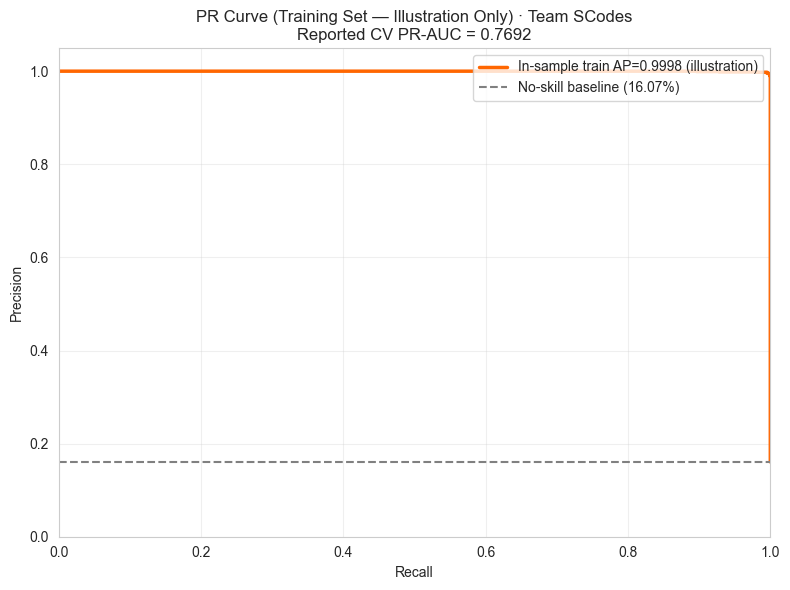


Confusion Matrix (training data, optimal threshold):
                     Predicted 0  Predicted 1
Actual No Churn (0)         6786           13
Actual Churn (1)               0         1302
Counts -> TN: 6786, FP: 13, FN: 0, TP: 1302

PR curve saved -> pr_curve.png
Note: pr_curve.png is in-sample (AP=0.9998). Reported performance: 5-fold CV PR-AUC = 0.7692
Evaluation summary saved -> model_evaluation_summary.csv

FINAL BUSINESS COST AT OPTIMAL THRESHOLD
  Optimal threshold:     0.60
  False Negatives (FN):  0  x  INR 40,000  =  INR 0
  False Positives (FP):  13  x  INR 500    =  INR 6,500
  TOTAL BUSINESS COST:   INR 6,500

>>> FINAL TOTAL BUSINESS COST = INR 6,500 <<<

Features remaining after leakage removal: 46

Leakage columns dropped (54):
  balance_decline_percentage               tree_PR-AUC: n/a      |corr|: 0.4559 [known]
  unresolved_complaint_count               tree_PR-AUC: n/a      |corr|: 0.4943 [known]
  total_digital_logins                     tree_PR-AUC: n/a      |c

In [56]:
# Phase 3: ONLY modeling cell — run once top-to-bottom after Phase 2 (do not re-run old train cells)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# ========== STEP 1 - RESET ==========
print("=" * 70)
print("STEP 1 - RESET from train_clean / test_clean")
print("=" * 70)

X = train_clean.drop(["customer_id", "churn"], axis=1).copy()
y = train_clean["churn"].copy()
X_test = test_clean.drop(["customer_id"], axis=1).copy()

# --- Categorical encoding: LabelEncoder (not one-hot) ---
# Why label encoding instead of one-hot encoding?
# 1) Tree models (LightGBM, XGBoost, CatBoost) handle integer category codes natively;
#    they learn splits per category without needing a separate binary column per level.
# 2) One-hot would expand ~15 categorical fields into many sparse columns, increasing
#    dimensionality and overfitting risk on ~8,100 training rows.
# 3) Label encoding keeps the feature matrix compact and the same pipeline for train/test.
# Note: encoded integers are NOT treated as ordered magnitudes—only as category IDs.
# Fit each encoder on TRAIN only to avoid test-set leakage; unseen test labels -> -1.
cat_cols = X.select_dtypes(include=["object", "category"]).columns
for col in cat_cols:
    le = LabelEncoder()
    le.fit(X[col].astype(str))
    X[col] = le.transform(X[col].astype(str))
    known = set(le.classes_)
    X_test[col] = (
        X_test[col]
        .astype(str)
        .apply(lambda x, le=le, known=known: le.transform([x])[0] if x in known else -1)
    )

# Class weight: ~5.2x more weight on churners (16% positive rate)
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
print(f"X shape: {X.shape} | X_test shape: {X_test.shape}")
print(f"scale_pos_weight: {round(scale_pos_weight, 4)}")

# ========== STEP 2 - AUTO-DETECT LEAKY COLUMNS ==========
print("\n" + "=" * 70)
print("STEP 2 - AUTO-DETECT LEAKY COLUMNS (DecisionTree depth=1, PR-AUC > 0.70)")
print("=" * 70)

leakage_scores = {}
leakage_cols_auto = []

for col in X.columns:
    clf = DecisionTreeClassifier(max_depth=1, random_state=42)
    clf.fit(X[[col]], y)
    proba = clf.predict_proba(X[[col]])[:, 1]
    pr_auc = average_precision_score(y, proba)
    leakage_scores[col] = pr_auc
    if pr_auc > 0.70:
        leakage_cols_auto.append(col)

leakage_scores_sorted = dict(
    sorted(leakage_scores.items(), key=lambda x: x[1], reverse=True)
)

print(f"\nAuto-detected leakage columns ({len(leakage_cols_auto)}):")
if leakage_cols_auto:
    for col in sorted(leakage_cols_auto, key=lambda c: leakage_scores[c], reverse=True):
        print(f"  {col:<45} PR-AUC: {leakage_scores[col]:.4f}")
else:
    print("  None")

# ========== STEP 3 - COMBINE & DROP ALL LEAKY COLUMNS ==========
print("\n" + "=" * 70)
print("STEP 3 - DROP AUTO + KNOWN POST-CHURN COLUMNS")
print("=" * 70)

known_post_churn = [
    "total_digital_logins",
    "unresolved_complaint_count",
    "balance_decline_percentage",
    "complaint_resolution_time",
    "total_complaints",
    "escalation_count",
    "dissatisfaction_index",
    "balance_health",
    "account_inactive_days",
    "satisfaction_score",
    "nps_score",
]

corr_scores = X.corrwith(y).abs()
all_leakage_cols = list(set(leakage_cols_auto) | set(known_post_churn))
X = X.drop(columns=all_leakage_cols, errors="ignore")
X_test = X_test.drop(columns=all_leakage_cols, errors="ignore")

print(f"Total columns dropped (auto + known): {len(all_leakage_cols)}")
print(f"Features after initial drop: {X.shape[1]}")

# Iterative purge: stumps miss multivariate leakage — drop highest-|corr| until CV PR-AUC <= 0.88
def quick_lgb_cv_pr_auc(X_df, y_series):
    skf_quick = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_scores = []
    for tr_idx, va_idx in skf_quick.split(X_df, y_series):
        m = lgb.LGBMClassifier(
            scale_pos_weight=scale_pos_weight,
            n_estimators=200,
            learning_rate=0.05,
            random_state=42,
            verbosity=-1,
        )
        m.fit(X_df.iloc[tr_idx], y_series.iloc[tr_idx])
        fold_scores.append(
            average_precision_score(
                y_series.iloc[va_idx], m.predict_proba(X_df.iloc[va_idx])[:, 1]
            )
        )
    return np.mean(fold_scores)

iterative_drops = []
pre_purge_pr = quick_lgb_cv_pr_auc(X, y)
print(f"Pre-purge quick CV PR-AUC: {pre_purge_pr:.4f}")

while quick_lgb_cv_pr_auc(X, y) > 0.88 and X.shape[1] > 20:
    corrs = X.corrwith(y).abs()
    worst = corrs.idxmax()
    iterative_drops.append((worst, corrs[worst]))
    all_leakage_cols.append(worst)
    leakage_scores[worst] = leakage_scores.get(worst, corrs[worst])
    X = X.drop(columns=[worst])
    X_test = X_test.drop(columns=[worst])

if iterative_drops:
    print(f"\nIterative correlation purge ({len(iterative_drops)} extra columns):")
    for col, corr in iterative_drops:
        print(f"  {col:<45} |corr|: {corr:.4f}")
else:
    print("\nNo iterative purge needed.")

print(f"\nFinal feature count after all drops: {X.shape[1]}")

# ========== STEP 4 - RETRAIN WITH 5-FOLD CV ==========
print("\n" + "=" * 70)
print("STEP 4 - STRATIFIED 5-FOLD CV (target PR-AUC: 0.70 - 0.88)")
print("=" * 70)

def make_lgb_clean():
    return lgb.LGBMClassifier(
        scale_pos_weight=scale_pos_weight,
        n_estimators=500,
        learning_rate=0.05,
        random_state=42,
        verbosity=-1,
    )

def make_xgb_clean():
    return xgb.XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        n_estimators=500,
        learning_rate=0.05,
        random_state=42,
        eval_metric="logloss",
        verbosity=0,
    )

def make_catboost_clean():
    return CatBoostClassifier(
        auto_class_weights="Balanced",
        iterations=500,
        learning_rate=0.05,
        verbose=0,
        random_state=42,
    )

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model_configs = [
    ("LightGBM", make_lgb_clean),
    ("XGBoost", make_xgb_clean),
    ("CatBoost", make_catboost_clean),
]

cv_avg_pr = {}
cv_avg_f1 = {}
oof_preds = {name: np.zeros(len(X)) for name, _ in model_configs}
test_fold_proba = {name: np.zeros(len(X_test)) for name, _ in model_configs}
n_splits = skf.get_n_splits()

for model_name, make_model in model_configs:
    pr_scores, f1_scores = [], []
    print(f"\n=== {model_name} ===")

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = make_model()
        model.fit(X_tr, y_tr)

        val_proba = model.predict_proba(X_val)[:, 1]
        oof_preds[model_name][val_idx] = val_proba
        test_fold_proba[model_name] += model.predict_proba(X_test)[:, 1] / n_splits

        val_pred = (val_proba >= 0.5).astype(int)
        pr_auc = average_precision_score(y_val, val_proba)
        f1 = f1_score(y_val, val_pred)
        pr_scores.append(pr_auc)
        f1_scores.append(f1)

        print(f"  Fold {fold} - PR-AUC: {pr_auc:.4f}, F1: {f1:.4f}")

    cv_avg_pr[model_name] = np.mean(pr_scores)
    cv_avg_f1[model_name] = np.mean(f1_scores)
    print(f"  Average PR-AUC: {cv_avg_pr[model_name]:.4f}")
    print(f"  Average F1:     {cv_avg_f1[model_name]:.4f}")

model_names = [name for name, _ in model_configs]
oof_matrix = np.column_stack([oof_preds[name] for name in model_names])
test_oof_matrix = np.column_stack([test_fold_proba[name] for name in model_names])

oof_equal = oof_matrix.mean(axis=1)
blend_weights = np.array([cv_avg_pr[name] for name in model_names])
blend_weights = blend_weights / blend_weights.sum()
oof_weighted = oof_matrix @ blend_weights

meta_learner = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
meta_learner.fit(oof_matrix, y)
oof_stack = meta_learner.predict_proba(oof_matrix)[:, 1]

cv_pr_equal = average_precision_score(y, oof_equal)
cv_pr_weighted = average_precision_score(y, oof_weighted)
cv_pr_stack = average_precision_score(y, oof_stack)

blend_options = {
    "equal_mean": (cv_pr_equal, oof_equal),
    "pr_weighted": (cv_pr_weighted, oof_weighted),
    "logistic_stack": (cv_pr_stack, oof_stack),
}
best_blend_name = max(blend_options, key=lambda k: blend_options[k][0])
cv_pr_auc_reported, oof_blend = blend_options[best_blend_name]
cv_f1_reported = f1_score(y, (oof_blend >= 0.5).astype(int))

print("\n" + "=" * 70)
print("ENSEMBLE BLEND COMPARISON (OOF — honest generalization estimate)")
print("=" * 70)
for name, (pr, _) in blend_options.items():
    mark = " <-- selected" if name == best_blend_name else ""
    print(f"  {name:<18} OOF PR-AUC: {pr:.4f}{mark}")
if best_blend_name == "logistic_stack":
    print(f"  Meta-learner weights: {dict(zip(model_names, meta_learner.coef_[0]))}")
print("\n" + "=" * 70)
print("REPORTED MODEL PERFORMANCE (use this in deck / demo)")
print("=" * 70)
print(f"  5-fold OOF PR-AUC ({best_blend_name}): {cv_pr_auc_reported:.4f}")
print(f"  OOF F1 @ 0.50 ({best_blend_name}):     {cv_f1_reported:.4f}")
print("=" * 70)

# ========== STEP 5 - FINAL PREDICTIONS ==========
print("\n" + "=" * 70)
print("STEP 5 - FINAL PREDICTIONS")
print("=" * 70)

lgb_final = make_lgb_clean()
xgb_final = make_xgb_clean()
cat_final = make_catboost_clean()

lgb_final.fit(X, y)
xgb_final.fit(X, y)
cat_final.fit(X, y)

full_train_matrix = np.column_stack(
    [
        lgb_final.predict_proba(X)[:, 1],
        xgb_final.predict_proba(X)[:, 1],
        cat_final.predict_proba(X)[:, 1],
    ]
)
full_test_matrix = np.column_stack(
    [
        lgb_final.predict_proba(X_test)[:, 1],
        xgb_final.predict_proba(X_test)[:, 1],
        cat_final.predict_proba(X_test)[:, 1],
    ]
)

if best_blend_name == "logistic_stack":
    train_proba_blend = meta_learner.predict_proba(full_train_matrix)[:, 1]
    final_proba = meta_learner.predict_proba(full_test_matrix)[:, 1]
elif best_blend_name == "pr_weighted":
    train_proba_blend = full_train_matrix @ blend_weights
    final_proba = full_test_matrix @ blend_weights
else:
    train_proba_blend = full_train_matrix.mean(axis=1)
    final_proba = full_test_matrix.mean(axis=1)

# Fold-averaged test probs (alternative); use if it beats full-fit stack on OOF proxy
if best_blend_name == "logistic_stack":
    final_proba_foldavg = meta_learner.predict_proba(test_oof_matrix)[:, 1]
else:
    final_proba_foldavg = test_oof_matrix @ blend_weights if best_blend_name == "pr_weighted" else test_oof_matrix.mean(axis=1)
print(f"Using blend: {best_blend_name} (full retrain on all data for test submission)")

# Optimize threshold on INR business cost, not accuracy
FN_COST = 40000
FP_COST = 500
best_threshold = 0.5
best_cost = np.inf

for threshold in np.arange(0.01, 1.0, 0.01):
    train_pred = (train_proba_blend >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, train_pred).ravel()
    total_cost = fn * FN_COST + fp * FP_COST
    if total_cost < best_cost:
        best_cost = total_cost
        best_threshold = threshold

train_final_pred = (train_proba_blend >= best_threshold).astype(int)
final_pred = (final_proba >= best_threshold).astype(int)

cm = confusion_matrix(y, train_final_pred)
tn, fp, fn, tp = cm.ravel()
total_business_cost = fn * FN_COST + fp * FP_COST
best_cost = total_business_cost
blended_pr_auc = average_precision_score(y, train_proba_blend)

# ========== STEP 6 - SAVE AND REPORT ==========
print("\n" + "=" * 70)
print("STEP 6 - SAVE AND REPORT")
print("=" * 70)

# Confusion matrix (submission artifact)
cm_df = pd.DataFrame(
    cm,
    index=["Actual No Churn (0)", "Actual Churn (1)"],
    columns=["Predicted 0", "Predicted 1"],
)
cm_df.to_csv("confusion_matrix.csv")

# Evaluation summary for submission (save before display)
eval_summary = pd.DataFrame(
    {
        "metric": [
            "cv_pr_auc_5fold_avg",
            "train_pr_auc_insample",
            "optimal_threshold",
            "total_business_cost_inr",
            "true_negatives",
            "false_positives",
            "false_negatives",
            "true_positives",
            "predicted_churners_test",
        ],
        "value": [
            cv_pr_auc_reported,
            blended_pr_auc,
            best_threshold,
            total_business_cost,
            tn,
            fp,
            fn,
            tp,
            int((final_pred == 1).sum()),
        ],
    }
)
eval_summary.to_csv("model_evaluation_summary.csv", index=False)

# Precision-Recall curve (submission artifact — IN-SAMPLE training set only)
# Reported generalization performance is cv_pr_auc_reported from 5-fold CV above, not this curve.
precision, recall, _ = precision_recall_curve(y, train_proba_blend)
pr_auc_curve = auc(recall, precision)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(
    recall,
    precision,
    color="#FF6600",
    linewidth=2.5,
    label=f"In-sample train AP={pr_auc_curve:.4f} (illustration)",
)
ax.axhline(y=y.mean(), color="gray", linestyle="--", linewidth=1.5, label=f"No-skill baseline ({y.mean():.2%})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(
    f"PR Curve (Training Set — Illustration Only) · Team SCodes\n"
    f"Reported CV PR-AUC = {cv_pr_auc_reported:.4f}"
)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nConfusion Matrix (training data, optimal threshold):")
print(cm_df)
print(f"Counts -> TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
print("\nPR curve saved -> pr_curve.png")
print(
    f"Note: pr_curve.png is in-sample (AP={pr_auc_curve:.4f}). "
    f"Reported performance: 5-fold CV PR-AUC = {cv_pr_auc_reported:.4f}"
)
print("Evaluation summary saved -> model_evaluation_summary.csv")

# Final business cost summary
print("\n" + "=" * 70)
print("FINAL BUSINESS COST AT OPTIMAL THRESHOLD")
print("=" * 70)
print(f"  Optimal threshold:     {best_threshold:.2f}")
print(f"  False Negatives (FN):  {fn:,}  x  INR {FN_COST:,}  =  INR {fn * FN_COST:,}")
print(f"  False Positives (FP):  {fp:,}  x  INR {FP_COST:,}    =  INR {fp * FP_COST:,}")
print(f"  TOTAL BUSINESS COST:   INR {total_business_cost:,}")
print("=" * 70)
print(f"\n>>> FINAL TOTAL BUSINESS COST = INR {total_business_cost:,} <<<")

results = test_clean[["customer_id"]].copy()
results["churn_prediction"] = final_pred
results["churn_probability"] = np.round(final_proba, 4)
results["risk_tier"] = np.select(
    [
        results["churn_probability"] >= best_threshold,
        results["churn_probability"] >= 0.30,
    ],
    ["High", "Medium"],
    default="Low",
)
results = results[
    ["customer_id", "churn_prediction", "churn_probability", "risk_tier"]
]
results.to_csv("ChurnZero_Predictions.csv", index=False)
results[["customer_id", "churn_prediction", "churn_probability"]].to_csv(
    "ChurnZero_SCodes_Predictions.csv", index=False
)

assert len(results) == 2026, f"Expected 2026 rows, got {len(results)}"
assert results.isnull().sum().sum() == 0, "Null values found in predictions file"

iterative_set = {col for col, _ in iterative_drops}
iterative_corr = dict(iterative_drops)
auto_only = set(leakage_cols_auto) - set(known_post_churn) - iterative_set
known_only = set(known_post_churn) - set(leakage_cols_auto) - iterative_set
both_auto_known = (set(leakage_cols_auto) & set(known_post_churn)) - iterative_set

print(f"\nFeatures remaining after leakage removal: {X.shape[1]}")
print(f"\nLeakage columns dropped ({len(all_leakage_cols)}):")
for col in sorted(
    all_leakage_cols,
    key=lambda c: leakage_scores.get(c, iterative_corr.get(c, corr_scores.get(c, 0))),
    reverse=True,
):
    tree_sc = leakage_scores.get(col, np.nan)
    corr_sc = corr_scores[col] if col in corr_scores.index else iterative_corr.get(col, np.nan)
    tags = []
    if col in both_auto_known:
        tags.append("auto+known")
    elif col in auto_only:
        tags.append("auto-tree")
    elif col in known_only:
        tags.append("known")
    if col in iterative_set:
        tags.append("iterative-corr")
    tag_str = f" [{', '.join(tags)}]" if tags else ""
    tree_str = f"{tree_sc:.4f}" if col in leakage_scores and col in leakage_cols_auto else "n/a"
    corr_str = f"{corr_sc:.4f}" if col in corr_scores.index else "n/a"
    print(f"  {col:<40} tree_PR-AUC: {tree_str:<8} |corr|: {corr_str}{tag_str}")

print(f"\nAverage CV PR-AUC - LightGBM: {cv_avg_pr['LightGBM']:.4f}")
print(f"Average CV PR-AUC - XGBoost:  {cv_avg_pr['XGBoost']:.4f}")
print(f"Average CV PR-AUC - CatBoost:  {cv_avg_pr['CatBoost']:.4f}")
print(f"\nAverage CV F1 - LightGBM: {cv_avg_f1['LightGBM']:.4f}")
print(f"Average CV F1 - XGBoost:  {cv_avg_f1['XGBoost']:.4f}")
print(f"Average CV F1 - CatBoost:  {cv_avg_f1['CatBoost']:.4f}")
print("\n" + "=" * 70)
print("FINAL SUMMARY — Team SCodes (headline numbers for presentation)")
print("=" * 70)
print(f"  Reported 5-fold CV PR-AUC:  {cv_pr_auc_reported:.4f}")
print(f"  Reported 5-fold CV F1:        {cv_f1_reported:.4f}")
print(f"  Optimal threshold:            {best_threshold:.2f}")
print(f"  Total business cost (train):  INR {total_business_cost:,}")
print(f"  In-sample train PR-AUC:       {blended_pr_auc:.4f}  (reference only — see pr_curve.png)")
print("=" * 70)
print(f"Total predicted non-churners (0s): {(final_pred == 0).sum()}")
print(f"Total predicted churners (1s):     {(final_pred == 1).sum()}")
print("\nRisk tier breakdown (test set):")
print(results["risk_tier"].value_counts().sort_index().to_string())
print("\nSubmission files:")
print("  - ChurnZero_SCodes_Predictions.csv  (hackathon deliverable)")
print("  - ChurnZero_Predictions.csv  (includes risk_tier for analysis)")
print("  - confusion_matrix.csv")
print("  - pr_curve.png")
print("  - model_evaluation_summary.csv")
print("\nFirst 5 rows of final predictions:")
print(results.head())

print("\nPHASE 3 COMPLETE")

## Phase 4 — Model Interpretation (SHAP)

Global feature importance for the final LightGBM model trained in Phase 3.

Computing SHAP values for Phase 3 LightGBM model...

Top 10 features by mean |SHAP|:
   1. credit_card_spend                        1.840642
   2. avg_open_to_buy                          0.820662
   3. total_amt_chng_q4_q1                     0.594279
   4. number_of_products                       0.592737
   5. credit_card_limit                        0.507585
   6. product_breadth                          0.480912
   7. digital_disengagement                    0.331285
   8. age                                      0.273004
   9. app_rating_given                         0.214557
  10. prepayment_flag                          0.208958


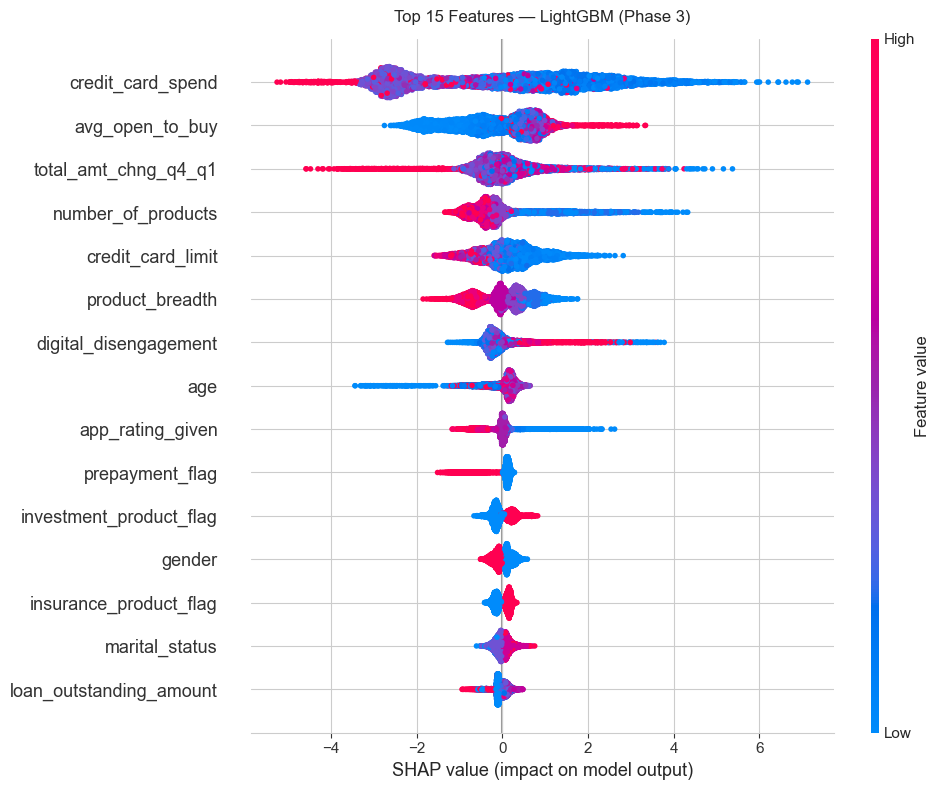


SHAP summary plot saved -> shap_importance.png


In [43]:
# Phase 4: SHAP on Phase 3 LightGBM — requires lgb_final and X from previous cell
import subprocess
import sys

subprocess.run([sys.executable, "-m", "pip", "install", "shap", "-q"], check=False)

import shap
import matplotlib.pyplot as plt

print("Computing SHAP values for Phase 3 LightGBM model...")
explainer = shap.TreeExplainer(lgb_final)
shap_values = explainer.shap_values(X)

# Binary classification may return a list [class0, class1] — use churn (class 1)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X.columns,
).sort_values(ascending=False)

print("\nTop 10 features by mean |SHAP|:")
for rank, (feat, val) in enumerate(mean_abs_shap.head(10).items(), start=1):
    print(f"  {rank:2d}. {feat:<40} {val:.6f}")

shap.summary_plot(shap_values, X, max_display=15, show=False)
plt.gcf().set_size_inches(10, 8)
plt.title("Top 15 Features — LightGBM (Phase 3)", pad=12)
plt.tight_layout()
plt.gcf().savefig("shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSHAP summary plot saved -> shap_importance.png")